# Figures that combine time feature (daily, weekly, weekend, monthly, quarterly, yearly) with 5 combinations

- With Solar
- Without Solar
- With Solar + Heat Pump
- With Solar + EV
- Without Solar + EV

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools


# Set plot style
plt.style.use('ggplot')
sns.set(style="whitegrid")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [8]:
# Path to the pickle file
file_path = "/Users/agetman/Desktop/Twork/energyThesis/data/data_clean/clean_v2.pkl"

# Load the pickle file into df
df = pd.read_pickle(file_path)

# Verify the data loaded correctly
print(f"DataFrame loaded with {len(df)} rows and {len(df.columns)} columns")
df.info()

DataFrame loaded with 6000000 rows and 18 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 18 columns):
 #   Column                      Dtype              
---  ------                      -----              
 0   EAN_ID                      int64              
 1   Date                        datetime64[ns]     
 2   Date_StartHour              datetime64[ns, UTC]
 3   Volume_Consumption_kWh      float64            
 4   Volume_Injection_kWh        float64            
 5   Heat_Pump_Indicator         int64              
 6   Electric_Vehicle_Indicator  int64              
 7   PV_Installation_Indicator   int64              
 8   Contract_Category           object             
 9   Hour                        int32              
 10  Minute                      int32              
 11  Day                         int32              
 12  Month                       int32              
 13  Year                        int32    

In [9]:
df

,EAN_ID,Date,Date_StartHour,Volume_Consumption_kWh,Volume_Injection_kWh,Heat_Pump_Indicator,Electric_Vehicle_Indicator,PV_Installation_Indicator,Contract_Category,Hour,Minute,Day,Month,Year,Day_of_Week_Name,With_HeatPump_Solar,With_Solar_EV,Without_Solar_With_EV
0,1,2022-01-01,2022-01-01 00:00:00+00:00,0.760,0.0,0,1,0,Residentieel,0,0,1,1,2022,Saturday,0,0,1
1,1,2022-01-01,2022-01-01 00:15:00+00:00,0.789,0.0,0,1,0,Residentieel,0,15,1,1,2022,Saturday,0,0,1
2,1,2022-01-01,2022-01-01 00:30:00+00:00,1.131,0.0,0,1,0,Residentieel,0,30,1,1,2022,Saturday,0,0,1
3,1,2022-01-01,2022-01-01 00:45:00+00:00,0.791,0.0,0,1,0,Residentieel,0,45,1,1,2022,Saturday,0,0,1
4,1,2022-01-01,2022-01-01 01:00:00+00:00,0.791,0.0,0,1,0,Residentieel,1,0,1,1,2022,Saturday,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5999995,172,2022-03-26,2022-03-26 22:45:00+00:00,0.030,0.0,0,0,0,Residentieel,22,45,26,3,2022,Saturday,0,0,0
5999996,172,2022-03-26,2022-03-26 23:00:00+00:00,0.027,0.0,0,0,0,Residentieel,23,0,26,3,2022,Saturday,0,0,0
5999997,172,2022-03-26,2022-03-26 23:15:00+00:00,0.025,0.0,0,0,0,Residentieel,23,15,26,3,2022,Saturday,0,0,0
5999998,172,2022-03-26,2022-03-26 23:30:00+00:00,0.039,0.0,0,0,0,Residentieel,23,30,26,3,2022,Saturday,0,0,0


In [10]:
# Total number of households
total_households = df['EAN_ID'].nunique()

# Number of households with solar
households_with_solar = df[df['PV_Installation_Indicator'] == 1]['EAN_ID'].nunique()

# Number of households without solar
households_without_solar = df[df['PV_Installation_Indicator'] == 0]['EAN_ID'].nunique()

# Number of households with solar and heat pump
households_with_solar_and_heat_pump = df[(df['PV_Installation_Indicator'] == 1) & (df['Heat_Pump_Indicator'] == 1)]['EAN_ID'].nunique()

# Number of households with solar and EV
households_with_solar_and_ev = df[(df['PV_Installation_Indicator'] == 1) & (df['Electric_Vehicle_Indicator'] == 1)]['EAN_ID'].nunique()

# Number of households without solar but with EV
households_without_solar_with_ev = df[(df['PV_Installation_Indicator'] == 0) & (df['Electric_Vehicle_Indicator'] == 1)]['EAN_ID'].nunique()

# Print the results
print(f"Total number of households: {total_households}")
print(f"Number of households with solar: {households_with_solar}")
print(f"Number of households without solar: {households_without_solar}")
print(f"Number of households with solar and heat pump: {households_with_solar_and_heat_pump}")
print(f"Number of households with solar and EV: {households_with_solar_and_ev}")
print(f"Number of households without solar but with EV: {households_without_solar_with_ev}")

Total number of households: 172
Number of households with solar: 77
Number of households without solar: 95
Number of households with solar and heat pump: 11
Number of households with solar and EV: 31
Number of households without solar but with EV: 17


In [62]:
def plot_energy_data(df, focus='both', aggregation='sum', time_aggregation='hourly', plot_type='lineplot', save_path='/Users/agetman/Desktop/Twork/energyThesis/dataExploration/pltTimeSeries'):
    """
    Plot energy data for specific household categories and save the plots.

    Parameters:
    - df: DataFrame containing the data.
    - focus: 'consumption', 'injection', or 'both' to specify the focus of the plot.
    - aggregation: 'sum' or 'mean' to specify the aggregation method.
    - time_aggregation: 'weekday_weekend', 'hourly', 'daily', 'monthly', 'quarterly', or 'yearly' to specify the time aggregation.
    - plot_type: 'lineplot', 'barplot', or 'boxplot' to specify the type of plot.
    - save_path: Path to save the generated plots.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Validate focus
    if focus not in ['consumption', 'injection', 'both']:
        raise ValueError("Invalid focus. Choose from 'consumption', 'injection', or 'both'.")

    # Validate aggregation
    if aggregation not in ['sum', 'mean']:
        raise ValueError("Invalid aggregation. Choose from 'sum' or 'mean'.")

    # Validate time_aggregation
    if time_aggregation not in ['weekday_weekend', 'hourly', 'daily', 'monthly', 'quarterly', 'yearly']:
        raise ValueError("Invalid time_aggregation. Choose from 'weekday_weekend', 'hourly', 'daily', 'monthly', 'quarterly', or 'yearly'.")

    # Validate plot_type
    if plot_type not in ['lineplot', 'barplot', 'boxplot']:
        raise ValueError("Invalid plot_type. Choose from 'lineplot', 'barplot', or 'boxplot'.")

    # Ensure save_path exists
    os.makedirs(save_path, exist_ok=True)

    # Define grouping columns based on time_aggregation
    if time_aggregation == 'weekday_weekend':
        df['Weekday_Weekend'] = df['Day_of_Week_Name'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
        group_cols = ['Weekday_Weekend']
    elif time_aggregation == 'hourly':
        group_cols = ['Hour']
    elif time_aggregation == 'daily':
        group_cols = ['Day_of_Week_Name']
    elif time_aggregation == 'monthly':
        group_cols = ['Month']
        month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
        df['Month_Name'] = df['Month'].map(month_names)
    elif time_aggregation == 'quarterly':
        group_cols = ['Quarter', 'Year']
        df['Quarter'] = ((df['Month'] - 1) // 3) + 1
    elif time_aggregation == 'yearly':
        group_cols = ['Year']

    # Define household categories
    categories = {
        'With Solar': df[df['PV_Installation_Indicator'] == 1],
        'Without Solar': df[df['PV_Installation_Indicator'] == 0],
        'With Solar + Heat Pump': df[(df['PV_Installation_Indicator'] == 1) & (df['Heat_Pump_Indicator'] == 1)],
        'With Solar + EV': df[(df['PV_Installation_Indicator'] == 1) & (df['Electric_Vehicle_Indicator'] == 1)],
        'Without Solar + EV': df[(df['PV_Installation_Indicator'] == 0) & (df['Electric_Vehicle_Indicator'] == 1)],
    }

    # Plot data for each category
    plt.figure(figsize=(14, 8))
    for category, category_df in categories.items():
        if category_df.empty:
            continue

        # Define aggregation dictionary
        agg_dict = {}
        if focus in ['consumption', 'both']:
            agg_dict['Volume_Consumption_kWh'] = aggregation
        if focus in ['injection', 'both']:
            agg_dict['Volume_Injection_kWh'] = aggregation

        # Perform aggregation
        aggregated_data = category_df.groupby(group_cols).agg(agg_dict).reset_index()

        # Define x-axis values
        if time_aggregation == 'weekday_weekend':
            x = aggregated_data['Weekday_Weekend']
        elif time_aggregation == 'hourly':
            x = aggregated_data['Hour']
        elif time_aggregation == 'daily':
            day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
            aggregated_data['Day_Order'] = aggregated_data['Day_of_Week_Name'].map(lambda d: day_order.index(d))
            aggregated_data = aggregated_data.sort_values('Day_Order')
            x = aggregated_data['Day_of_Week_Name']
        elif time_aggregation == 'monthly':
            aggregated_data = aggregated_data.sort_values('Month')  # Ensure months are in order
            x = aggregated_data['Month'].map(month_names)
        elif time_aggregation == 'quarterly':
            x = 'Q' + aggregated_data['Quarter'].astype(str) + '-' + aggregated_data['Year'].astype(str)
        elif time_aggregation == 'yearly':
            x = aggregated_data['Year']

        # Plot the data based on plot_type
        if plot_type == 'lineplot':
            if focus in ['consumption', 'both']:
                sns.lineplot(x=x, y=aggregated_data['Volume_Consumption_kWh'], label=f'{category} - Consumption', marker='o')
            if focus in ['injection', 'both']:
                sns.lineplot(x=x, y=aggregated_data['Volume_Injection_kWh'], label=f'{category} - Injection', marker='o')
        elif plot_type == 'barplot':
            if focus in ['consumption', 'both']:
                sns.barplot(x=x, y=aggregated_data['Volume_Consumption_kWh'], label=f'{category} - Consumption', ci=None)
            if focus in ['injection', 'both']:
                sns.barplot(x=x, y=aggregated_data['Volume_Injection_kWh'], label=f'{category} - Injection', ci=None)
        elif plot_type == 'boxplot':
            if focus in ['consumption', 'both']:
                sns.boxplot(x=x, y=aggregated_data['Volume_Consumption_kWh'], label=f'{category} - Consumption')
            if focus in ['injection', 'both']:
                sns.boxplot(x=x, y=aggregated_data['Volume_Injection_kWh'], label=f'{category} - Injection')

    plt.title(f"{aggregation.capitalize()} {focus.capitalize()} Energy Data given Different Energy Sources ({time_aggregation.capitalize()})")
    plt.xlabel(time_aggregation.capitalize())
    plt.ylabel('Energy (kWh)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    # Save the plot
    file_name = f"{aggregation}_{time_aggregation}_energy_data_focus_{focus}_{plot_type}.png"
    plt.savefig(os.path.join(save_path, file_name), dpi=300)
    plt.show()

## Hourly

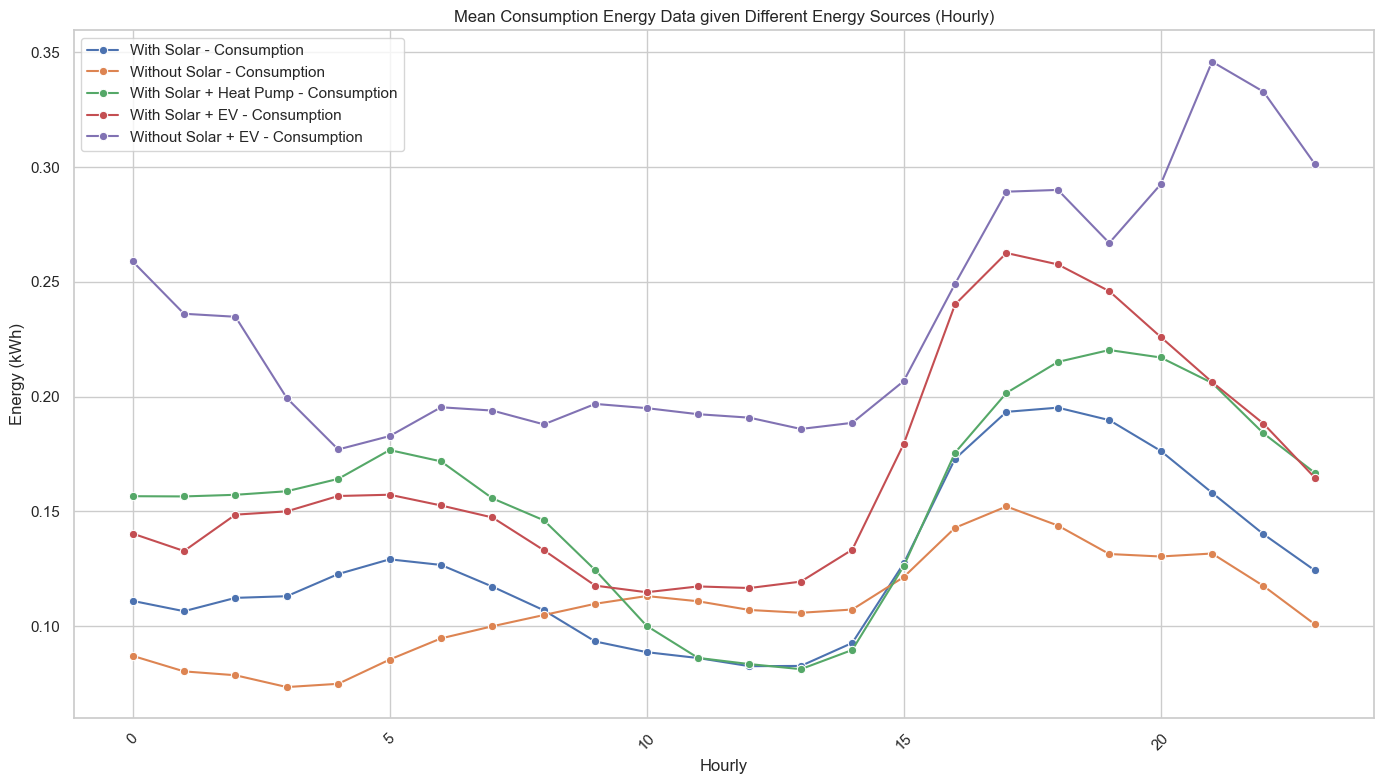

In [64]:
plot_energy_data(df, focus='consumption', aggregation='mean', time_aggregation='hourly', plot_type='lineplot')

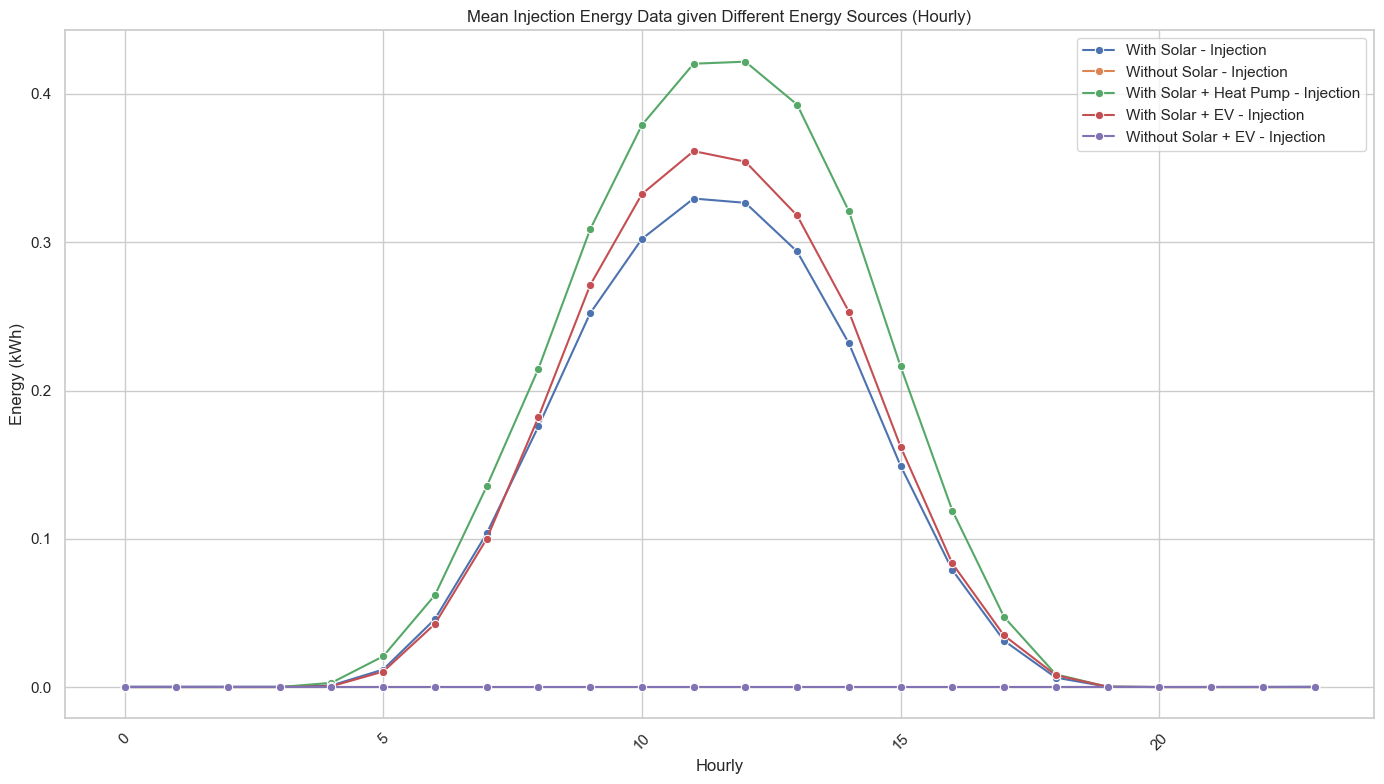

In [65]:
plot_energy_data(df, focus='injection', aggregation='mean', time_aggregation='hourly', plot_type='lineplot')

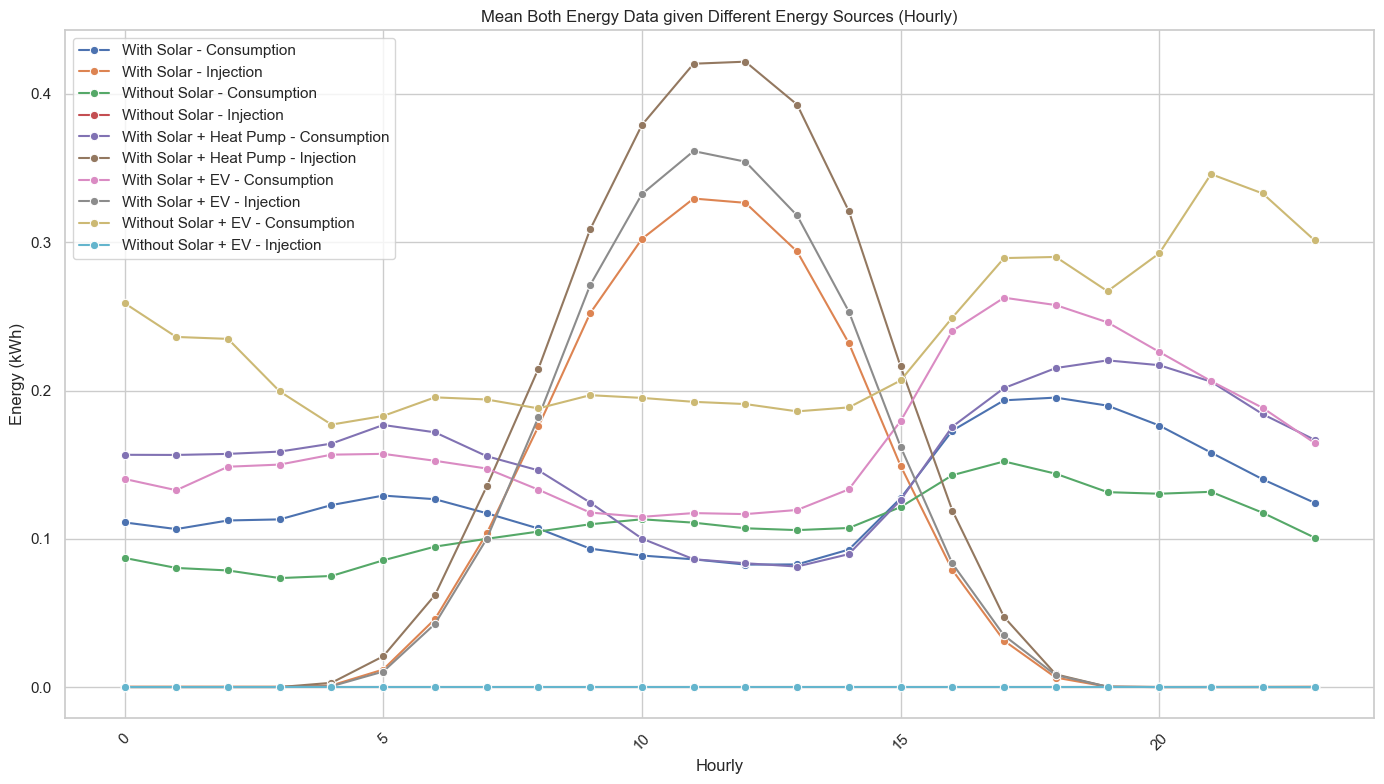

In [66]:
plot_energy_data(df, focus='both', aggregation='mean', time_aggregation='hourly', plot_type='lineplot')

## Daily

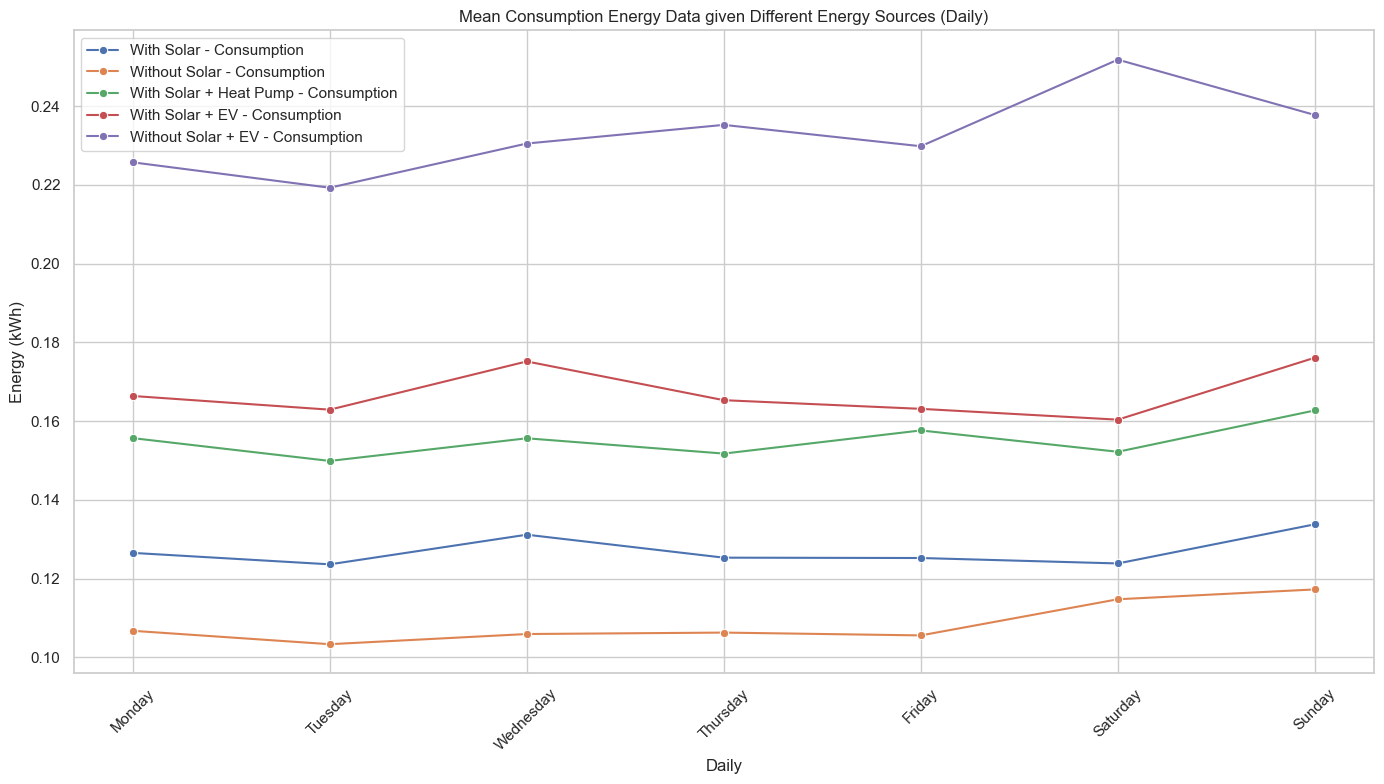

In [67]:
plot_energy_data(df, focus='consumption', aggregation='mean', time_aggregation='daily', plot_type='lineplot')

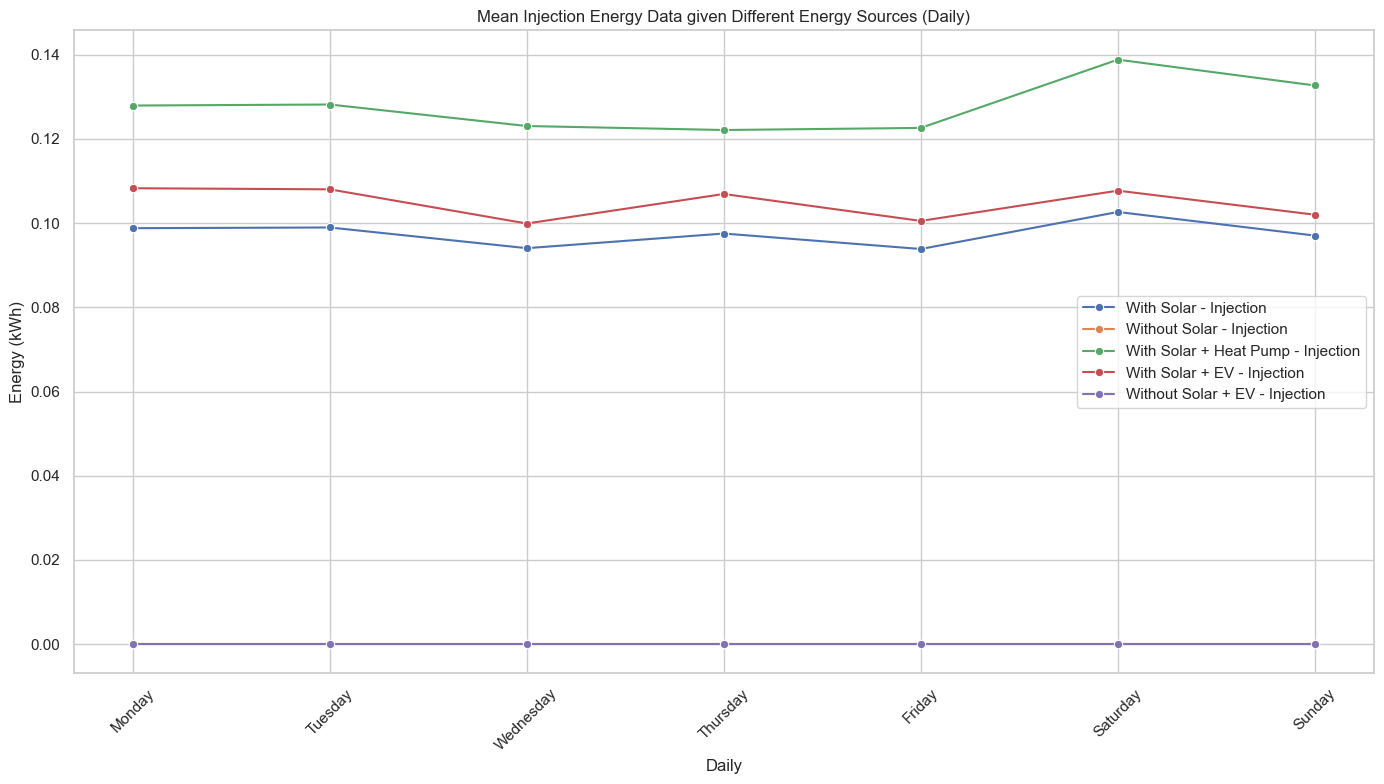

In [68]:
plot_energy_data(df, focus='injection', aggregation='mean', time_aggregation='daily', plot_type='lineplot')

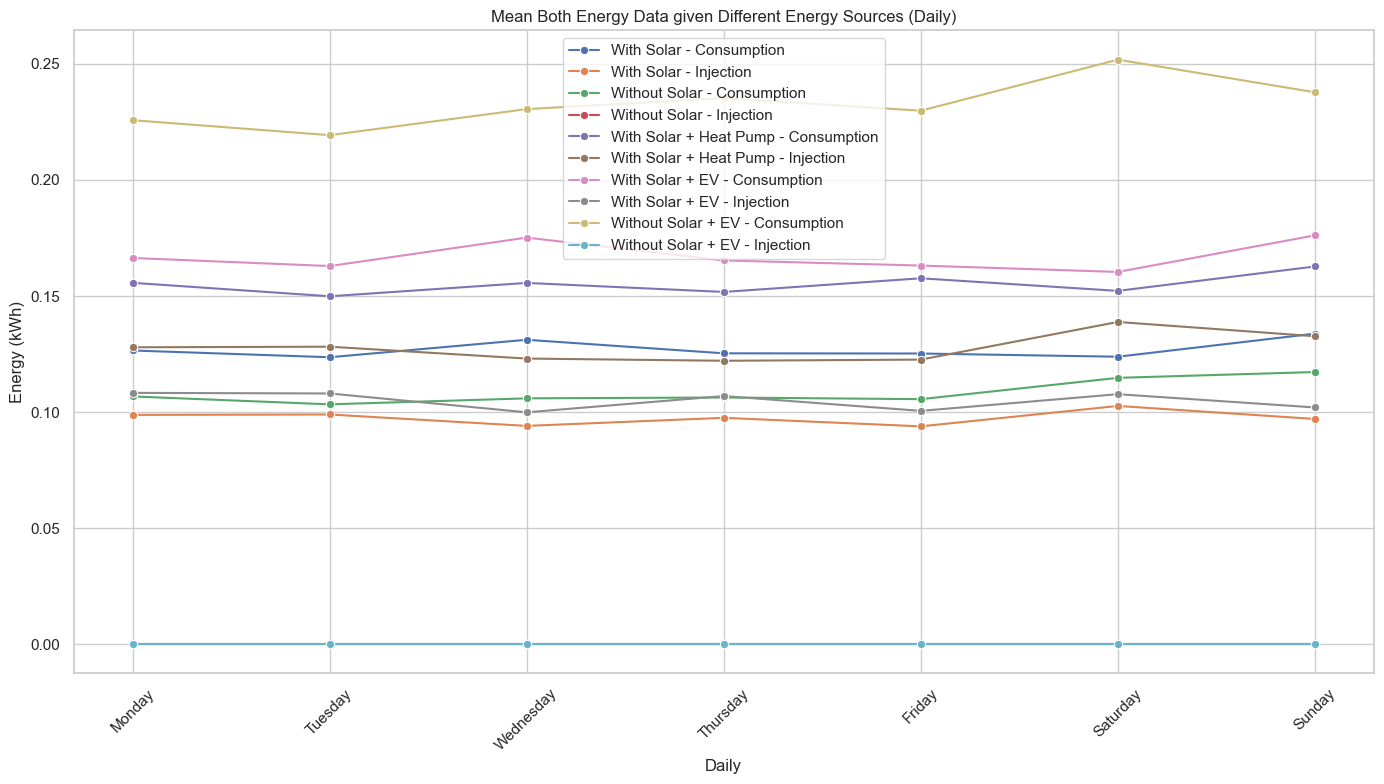

In [69]:
plot_energy_data(df, focus='both', aggregation='mean', time_aggregation='daily', plot_type='lineplot')

## Monthly

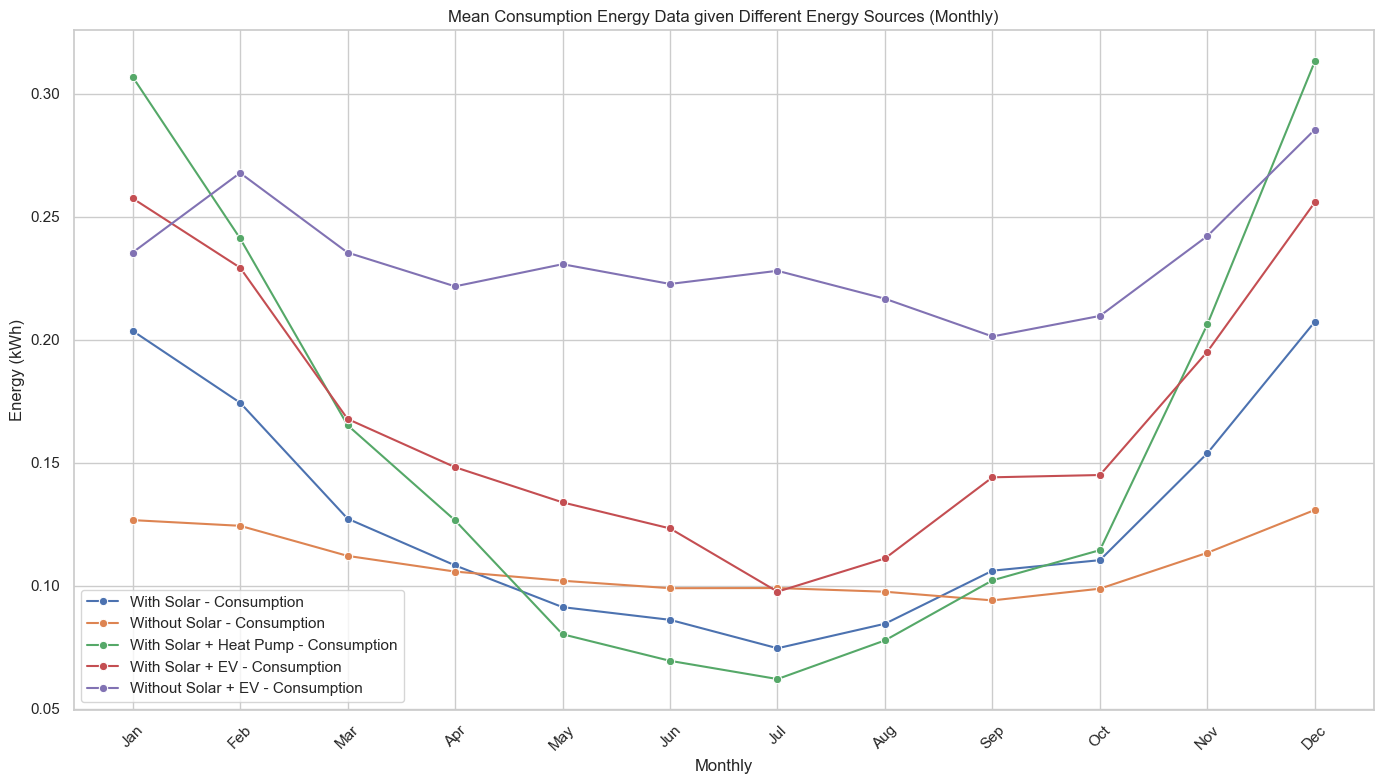

In [70]:
plot_energy_data(df, focus='consumption', aggregation='mean', time_aggregation='monthly', plot_type='lineplot')

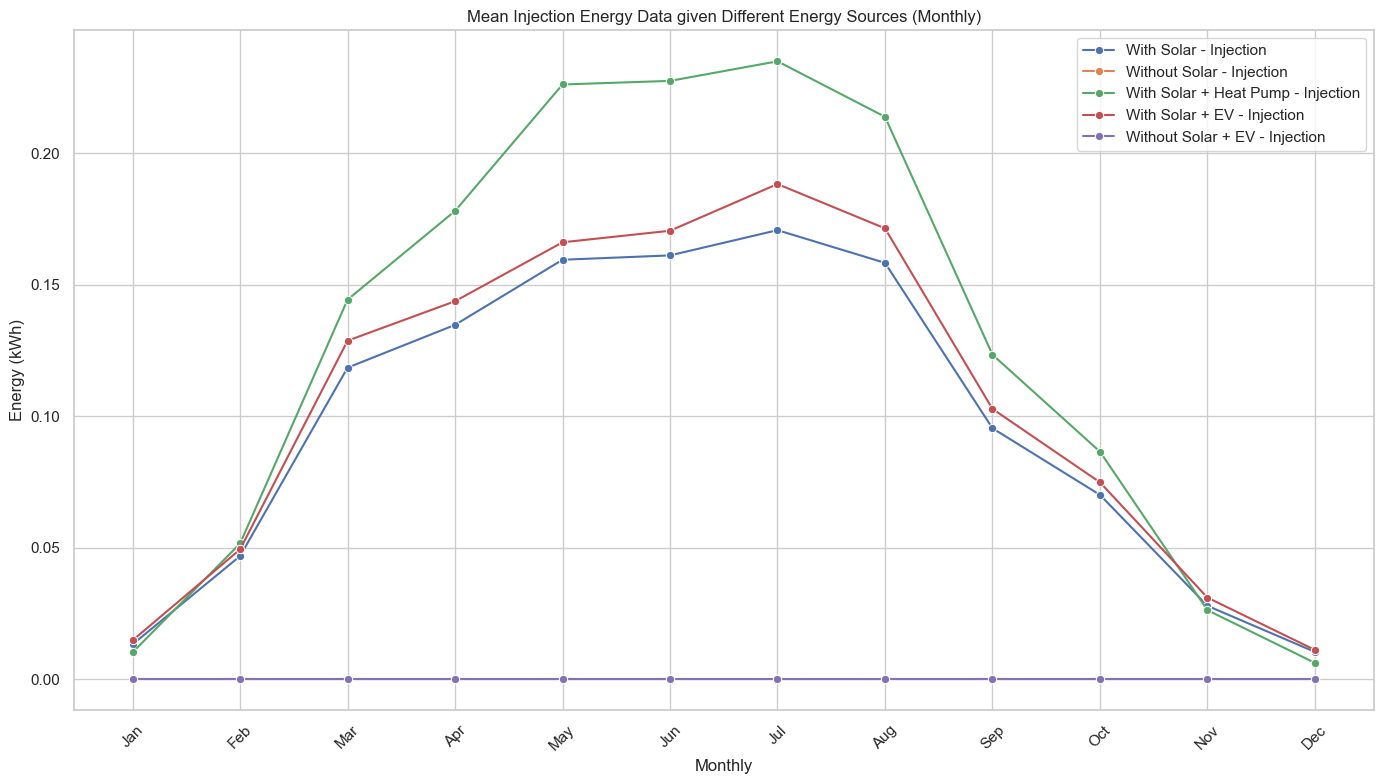

In [71]:
plot_energy_data(df, focus='injection', aggregation='mean', time_aggregation='monthly', plot_type='lineplot')

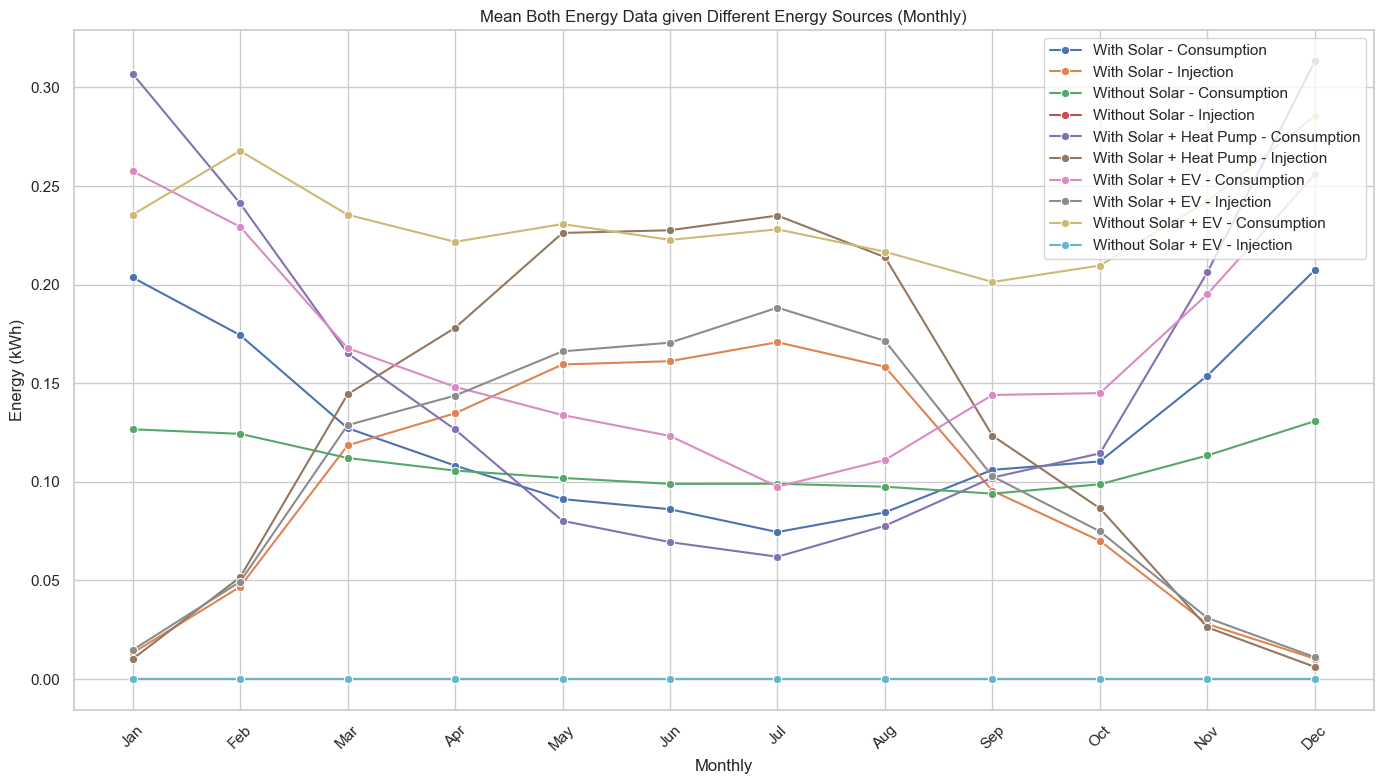

In [72]:
plot_energy_data(df, focus='both', aggregation='mean', time_aggregation='monthly', plot_type='lineplot')

## Quarterly

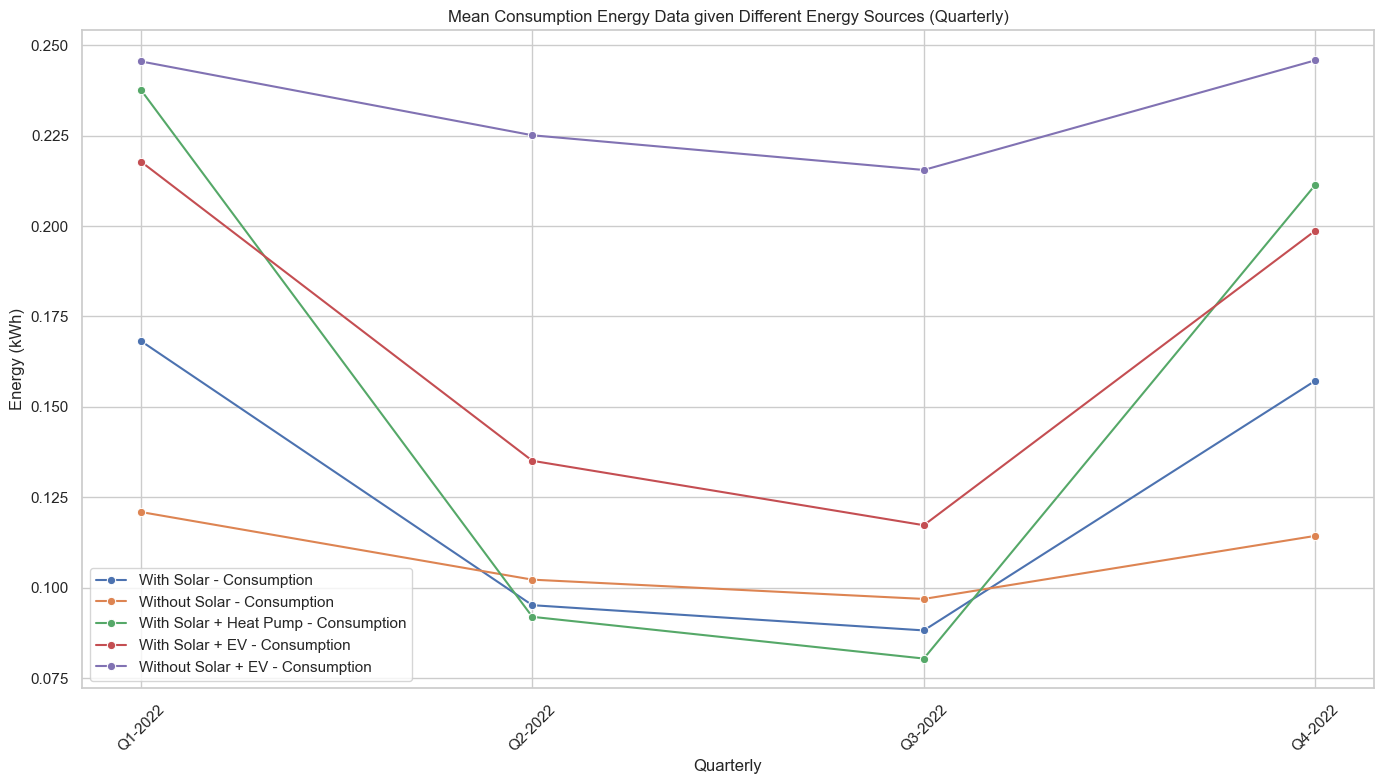

In [73]:
plot_energy_data(df, focus='consumption', aggregation='mean', time_aggregation='quarterly', plot_type='lineplot')

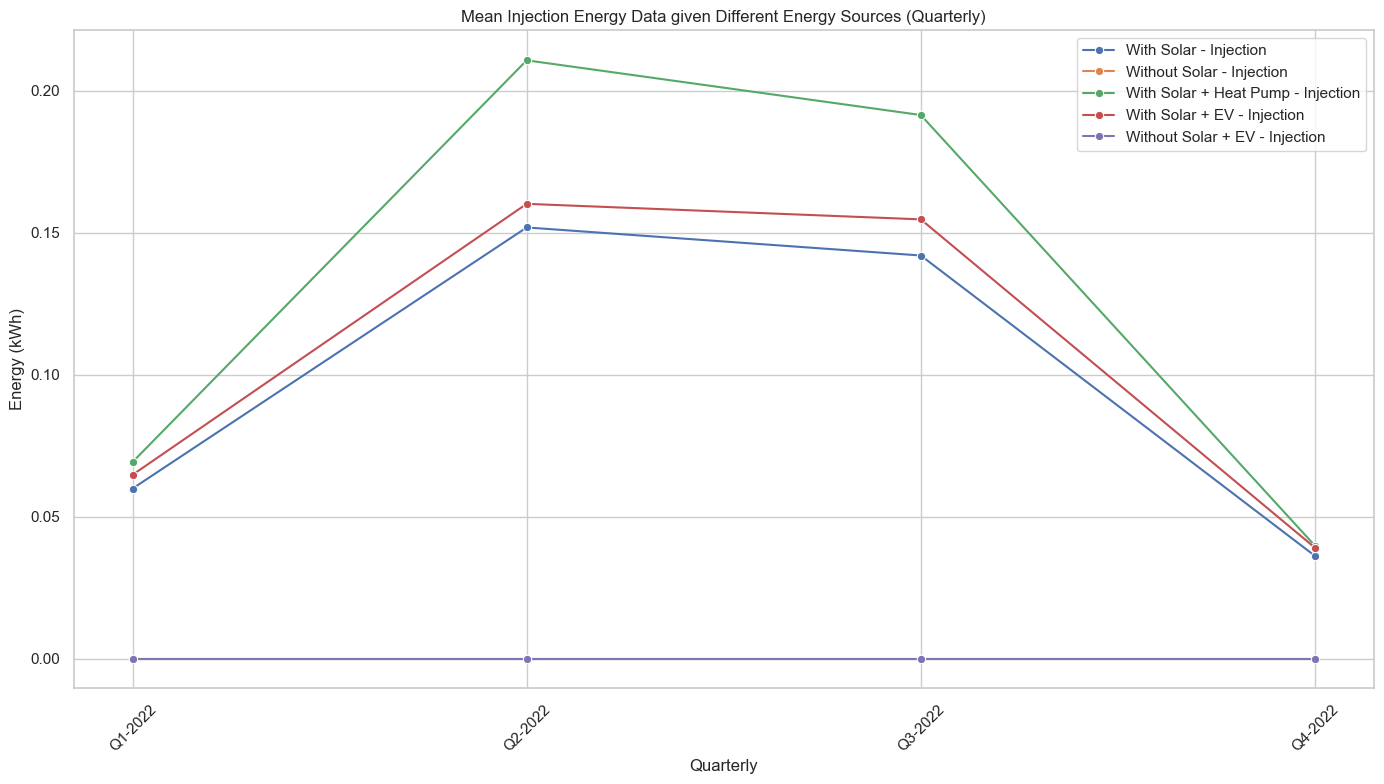

In [74]:
plot_energy_data(df, focus='injection', aggregation='mean', time_aggregation='quarterly', plot_type='lineplot')

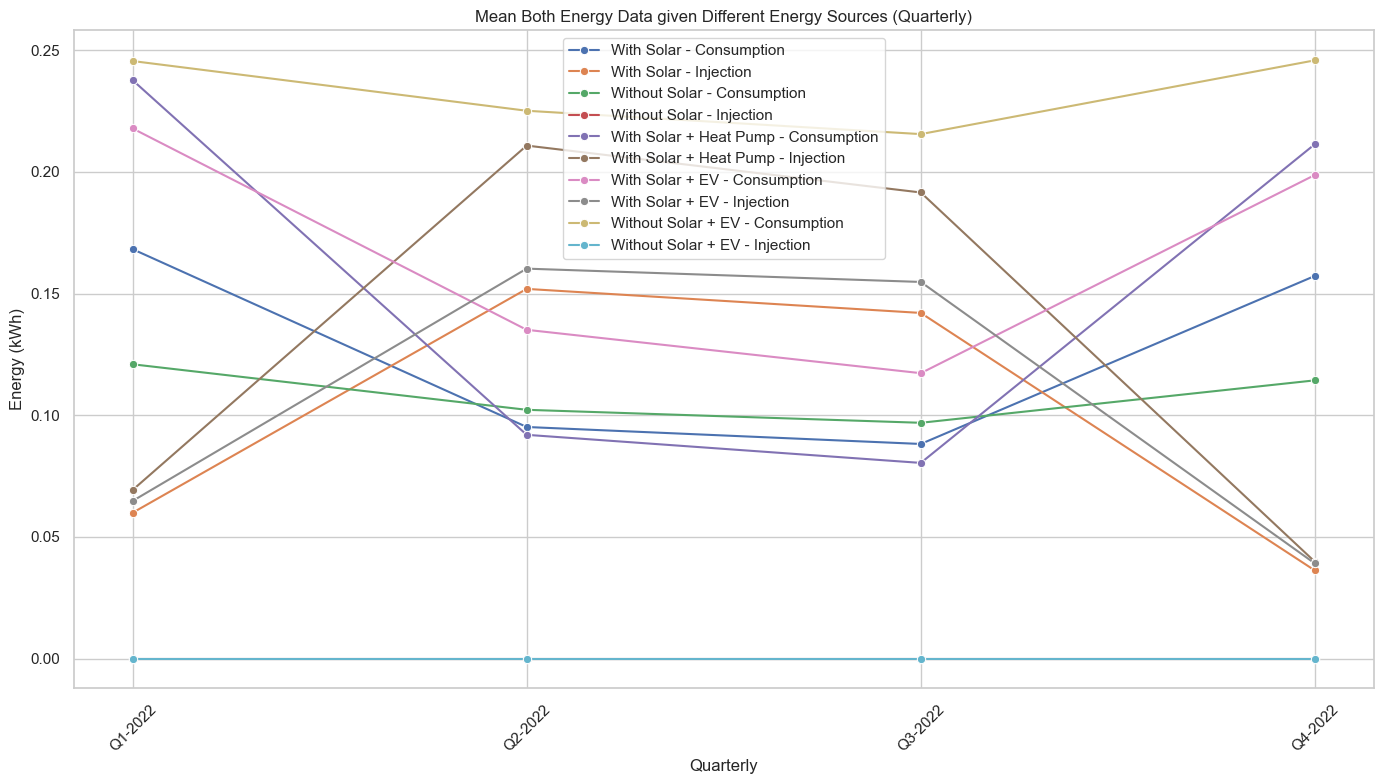

In [75]:
plot_energy_data(df, focus='both', aggregation='mean', time_aggregation='quarterly', plot_type='lineplot')